### Uber Supply Demand Gap Exploratory Data Analysis Project 

# **Project Name**    -  Uber EDA Project



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Name**            - NIKHIL SHARMA

# **Project Summary -**

**Uber Technologies, Inc. is an American multinational transportation company that provides ride-hailing services, courier services, food delivery, and freight transport.
It is headquartered in San Francisco, California, and operates in approximately 70 countries and 15,000 cities worldwide. 
It is the largest ridesharing company worldwide with over 180 million monthly active users and 6 million active drivers and couriers. 
It coordinates an average of 36 million trips and delivery orders per day, and has coordinated 64 billion trips and delivery orders since its inception in 2010.
In the second quarter of 2025, the company had a take rate (revenue as a percentage of gross bookings) of 30.6% for mobility services and 18.8% for food delivery.
We are given a dataset through which we have to analyze the demand and supply gap for Uber Company by doing EDA operation on given dataset.**

# **GitHub Link -**

**https://github.com/newuser0246/DataAnalyticsTraining**

# **Problem Statement**


**We have given a dataset on which we have to do EDA operation to analyze and solve problems for the Uber Demand Gap through it ?**

#### **Define Your Business Objective?**

**The following are the business objective for this project:-**

1) To find the reason of cancellation of cab rides by drivers.
2) To find the solution to increase the transparency of cab ride fairs.
3) To find the permanent solution to customer problems so that to increase customer engagement and customer statisfaction rate.
4) To find various method to increase customer engagement to use this app over other apps and ultimately increase profits for the organization.
5) To find solution to increase safety of cab rides specially in night time. 

## ***1. Know Your Data***

### Import Libraries

In [58]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm 
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import random
import ast
import statsmodels as stat

### Dataset Loading

In [59]:
# Load Dataset
md = pd.read_csv("Uber Request Data.csv")

### Dataset First View

In [60]:
# Dataset First Look
md.head(5)

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/07/16 11:51,11/07/16 13:00
1,867,Airport,1.0,Trip Completed,11/07/16 17:57,11/07/16 18:47
2,1807,City,1.0,Trip Completed,12/07/16 9:17,12/07/16 9:58
3,2532,Airport,1.0,Trip Completed,12/07/16 21:08,12/07/16 22:03
4,3112,City,1.0,Trip Completed,13/07/16 8:33,13/07/16 9:25


In [61]:
# Dataset tail look
md.tail(5)

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
6740,6745,City,NaN,No Cars Available,15/07/16 23:49,NaN
6741,6752,Airport,NaN,No Cars Available,15/07/16 23:50,NaN
6742,6751,City,NaN,No Cars Available,15/07/16 23:52,NaN
6743,6754,City,NaN,No Cars Available,15/07/16 23:54,NaN
6744,6753,Airport,NaN,No Cars Available,15/07/16 23:55,NaN


### Dataset Rows & Columns count

In [62]:
# Dataset Rows & Columns count
md.shape

(6745, 6)

### Dataset Information

In [63]:
# Dataset Info
md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


#### Duplicate Values

In [64]:
# Dataset Duplicate Value Count
# Check for duplicate values
duplicates = md.duplicated(keep=False)

# Count the duplicate values
duplicate_count = duplicates.value_counts()

print(duplicate_count)

False    6745
Name: count, dtype: int64


#### Missing Values/Null Values

In [65]:
# Missing Values/Null Values Count
md.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

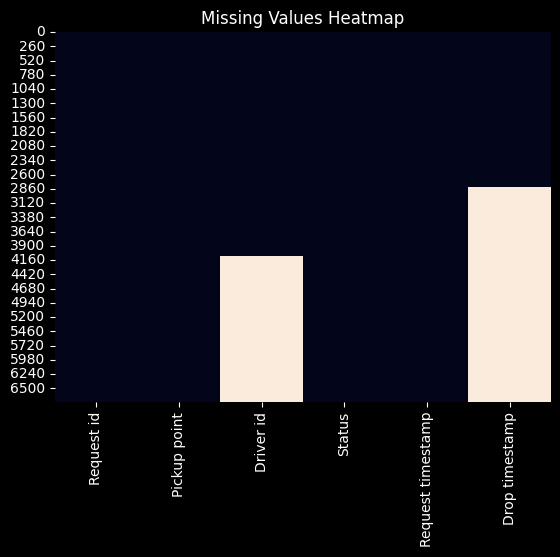

In [66]:
# Visualizing the missing values
plt.figure()
sns.heatmap(md.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

### What did you know about your dataset?

**The following are the major points about the dataset:-**

1) The dataset contains 6 columns and 6745 rows.
2) There are no duplicate values in the dataset.
3) The Heatmap gives the perfect distribution of data to see the missing values

**Follwoing 2 columns are having some missing values:-**

Driver id and 
Drop timestamp

## ***2. Understanding Your Variables***

In [67]:
# Dataset Columns
md.columns

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='object')

In [68]:
# Dataset Describe
md.describe()

,Request id,Driver id
count,6745.000000,4095.000000
mean,3384.644922,149.501343
std,1955.099667,86.051994
min,1.000000,1.000000
25%,1691.000000,75.000000
50%,3387.000000,149.000000
75%,5080.000000,224.000000
max,6766.000000,300.000000


### Variables Description

**The following are the variables with their description:-**

**Column names---------------------------Description**

1) Request id-------------------Customer Unique id who requested for the cab service through app.
2) Pickup point-----------------Pickup location to pickup the customer.
3) Driver id--------------------Unique Id of driver who is driving the cab.
4) Status-----------------------status of trip that if it got completed, cancelled or no cabs are available.
5) Request timestamp------------Request time and date when the customer requested for the cab service.
6) Drop timestamp---------------Drop time and date when the customer is dropped to their respective location.


The above are the descriptions for the variables present in the dataset.

### Check Unique Values for each variable.

In [69]:
# Check Unique Values for each variable.
for x in md.columns:
    print(f"{x} - {md[x].nunique()}") 

Request id - 6745
Pickup point - 2
Driver id - 300
Status - 3
Request timestamp - 4016
Drop timestamp - 2282


## 3. ***Data Wrangling***

### Data Wrangling Code

In [70]:
# Write your code to make your dataset analysis ready.
# checking for the null values in the dataset.
md.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

In [71]:
# Replacing the missing values with 'Not Available'
md.fillna({"Driver id": "Not Available"},inplace=True)

In [72]:
md.fillna({"Drop timestamp": "Not Available"},inplace=True)

In [73]:
# checking that the missing values are present or removed
md.isnull().sum()

Request id           0
Pickup point         0
Driver id            0
Status               0
Request timestamp    0
Drop timestamp       0
dtype: int64

### What all manipulations have you done and insights you found?

**The following manipulation we have done to our dataset:-**

There are total 2 columns having missing values , which are now replaced with "Not Available"

Driver id

Drop timestamp

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

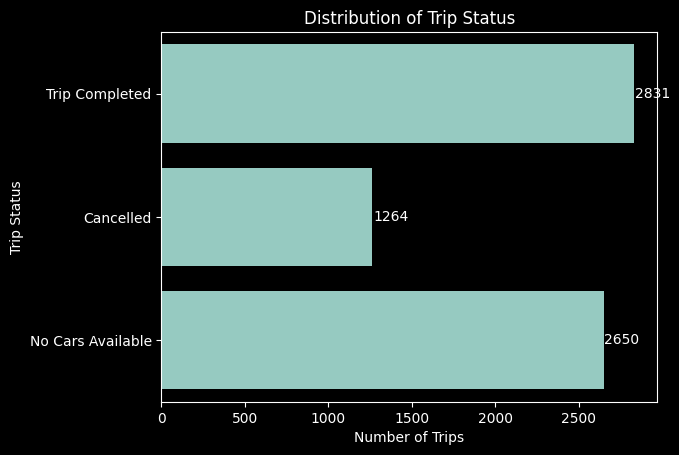

In [74]:
# Chart - 1 visualization code
import seaborn as sns
import matplotlib.pyplot as plt

# Set dark theme
plt.style.use('dark_background')

plt.figure()
ax = sns.countplot(y='Status', data=md)

plt.title("Distribution of Trip Status")
plt.xlabel("Number of Trips")
plt.ylabel("Trip Status")

# Add counts at bar tips
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 5,                 # position slightly outside bar
            p.get_y() + p.get_height()/2,
            int(width),
            va='center')

plt.show()

##### 1. Why did you pick the specific chart?

The above Horizontal bar plot gives clear count for each status type.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above bar plot:-

1) Highest count is for Trip completed status -> 2831.
2) Second highest count is for No Cars Available status -> 2650.
3) Lowest count is for Cancelled status -> 1264.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

I selected the horizontal bar chart because it clearly compares the number of Completed, Cancelled, and No Cars Available trips. It makes the supply–demand gap immediately visible and easy to interpret. The count labels improve clarity for decision-making. This visualization helps quickly identify operational inefficiencies affecting revenue and customer satisfaction.

The high number of Cancelled trips and No Cars Available requests indicates potential negative growth. Frequent cancellations reduce customer trust and increase the likelihood of users shifting to competitors. Similarly, ride unavailability during peak night hours leads to lost revenue opportunities. If unresolved, these operational gaps can directly impact customer retention and long-term revenue growth.

#### Chart - 2

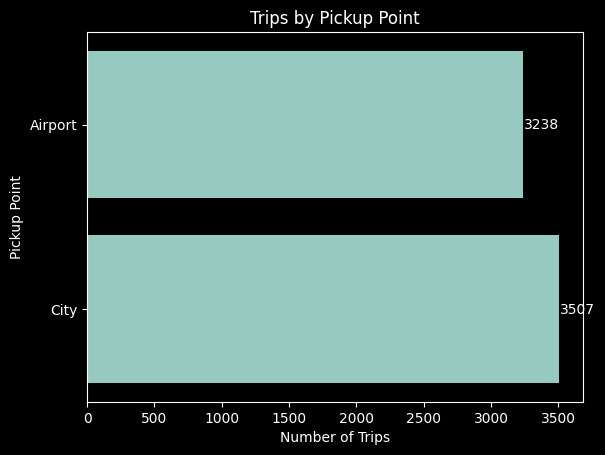

In [75]:
# Chart - 2 visualization code
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

plt.figure()
ax = sns.countplot(y='Pickup point', data=md)

plt.title("Trips by Pickup Point")
plt.xlabel("Number of Trips")
plt.ylabel("Pickup Point")

# Add count labels
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 5,
            p.get_y() + p.get_height()/2,
            int(width),
            va='center')

plt.show()

##### 1. Why did you pick the specific chart?

The above horizontal bar plot gives clear count for pickup points.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above horizontal bar plot:-

1) Highest count is for city pickup point -> 3507.
2) Lowest count is for airport pickup point -> 3238.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The horizontal plot reveals that one pickup point (especially Airport) has a higher concentration of failed trips, including cancellations and unavailability. This indicates operational inefficiencies in key high-demand areas. Such service gaps can reduce customer trust and lead to revenue loss. If not addressed, these issues may negatively impact long-term business growth and market competitiveness.

#### Chart - 3

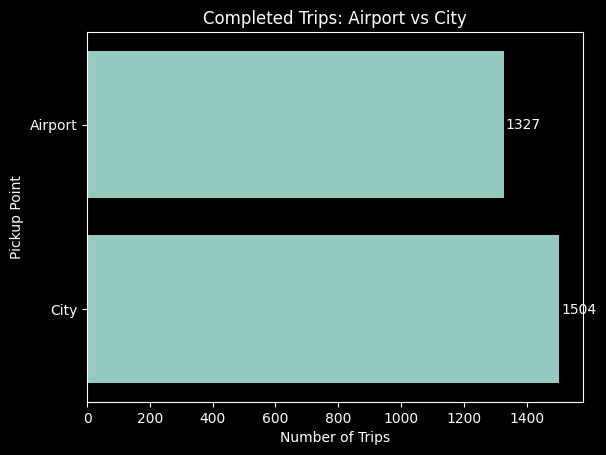

In [76]:
# Chart - 3 visualization code
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

completed_df = md[md['Status'] == 'Trip Completed']

plt.figure()
ax = sns.countplot(y='Pickup point', data=completed_df)

plt.title("Completed Trips: Airport vs City")
plt.xlabel("Number of Trips")
plt.ylabel("Pickup Point")

# Add count labels
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 5,
            p.get_y() + p.get_height()/2,
            int(width),
            va='center')

plt.show()

##### 1. Why did you pick the specific chart?

Separate horizontal bar charts were used to analyze Completed, Cancelled, and No Cars Available trips individually across Airport and City pickup points. This approach isolates each operational outcome, making it easier to identify location-specific inefficiencies. The count labels improve clarity and support data-driven decision-making.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above horizontal bar plot:-

1) For trip completed status the highest count is for city -> 1504.
2) For trip completed status the lowest count is for airport -> 1327.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

If Airport shows significantly fewer completed trips compared to City, it indicates underperformance in a high-demand, high-value location, potentially limiting revenue growth.

#### Chart - 4

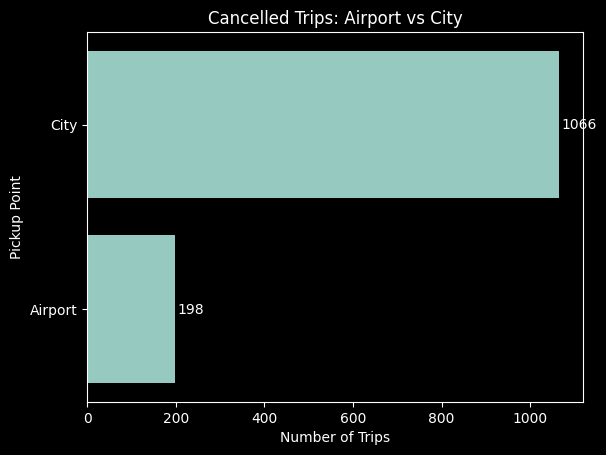

In [77]:
# Chart - 4 visualization code
cancelled_df = md[md['Status'] == 'Cancelled']

plt.figure()
ax = sns.countplot(y='Pickup point', data=cancelled_df)

plt.title("Cancelled Trips: Airport vs City")
plt.xlabel("Number of Trips")
plt.ylabel("Pickup Point")

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 5,
            p.get_y() + p.get_height()/2,
            int(width),
            va='center')

plt.show()

##### 1. Why did you pick the specific chart?

Separate horizontal bar charts were used to analyze Completed, Cancelled, and No Cars Available trips individually across Airport and City pickup points. This approach isolates each operational outcome, making it easier to identify location-specific inefficiencies. The count labels improve clarity and support data-driven decision-making.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above horizontal bar plot:-

1) For Cancelled Trips status the highest count is for city -> 1066.
2) For Cancelled Trips status the lowest count is for airport -> 198.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The significantly higher cancellations in the City indicate a major driver behavior issue in that location. Drivers may be rejecting short-distance trips, low-fare rides, or non-profitable routes. This can reduce customer satisfaction in core urban areas where ride frequency is high. If unresolved, it can weaken Uber’s dominance in its primary revenue-generating market.

#### Chart - 5

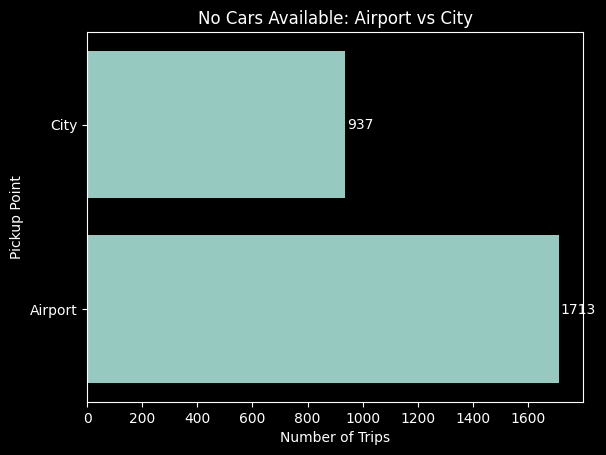

In [78]:
# Chart - 5 visualization code
no_car_df = md[md['Status'] == 'No Cars Available']

plt.figure()
ax = sns.countplot(y='Pickup point', data=no_car_df)

plt.title("No Cars Available: Airport vs City")
plt.xlabel("Number of Trips")
plt.ylabel("Pickup Point")

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 5,
            p.get_y() + p.get_height()/2,
            int(width),
            va='center')

plt.show()

##### 1. Why did you pick the specific chart?

Separate horizontal bar charts were used to analyze Completed, Cancelled, and No Cars Available trips individually across Airport and City pickup points. This approach isolates each operational outcome, making it easier to identify location-specific inefficiencies. The count labels improve clarity and support data-driven decision-making.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above horizontal bar plot:-

1) For no cars available status the highest count is for airport -> 1713.
2) For no cars available status the lowest count is for city -> 937.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The high “No Cars Available” count at the Airport highlights a critical supply-side failure in a high-demand zone. This leads to immediate revenue loss and risks losing high-value customers. If not addressed, it can negatively impact long-term growth and brand reliability.

To reduce high “No Cars Available” at the Airport, Uber should introduce targeted airport incentives and dynamic surge pricing to attract more drivers. Additionally, predictive demand planning based on flight arrival data can help pre-position drivers during peak hours. This will improve ride availability and reduce revenue loss.

#### Chart - 6

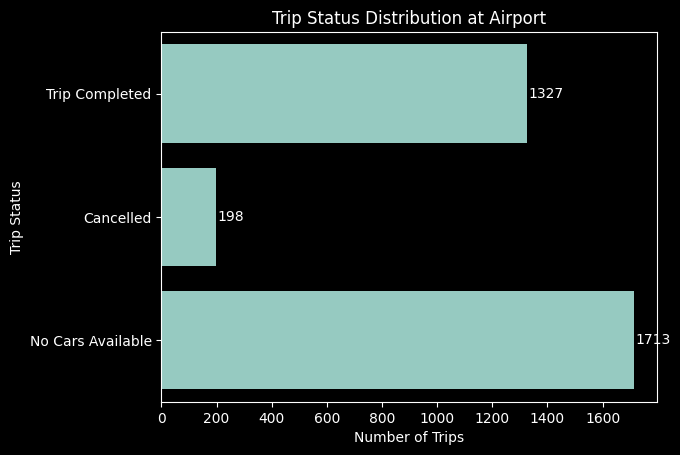

In [79]:
# Chart - 6 visualization code
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

airport_df = md[md['Pickup point'] == 'Airport']

plt.figure()
ax = sns.countplot(y='Status', data=airport_df)

plt.title("Trip Status Distribution at Airport")
plt.xlabel("Number of Trips")
plt.ylabel("Trip Status")

# Add count labels
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 5,
            p.get_y() + p.get_height()/2,
            int(width),
            va='center')

plt.show()

##### 1. Why did you pick the specific chart?

The above horizontal chart gives clear picture of the following :
1) Shows internal operational efficiency of Airport alone
2) Clearly highlights whether the problem is cancellation or supply shortage
3) Helps quantify revenue-impacting gaps

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above horizontal bar plot :-

1) Highest count of airport status is for No cars Available -> 1713.
2) Second highest count of airport status is for Trip Completed -> 1327.
3) Lowest count of airport status is for cancelled -> 198.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The airport data shows that the major problem is supply shortage rather than cancellations. With “No Cars Available” exceeding completed trips, Uber is losing significant revenue opportunities. Addressing driver allocation at the airport could substantially improve growth and service reliability.

To reduce high “No Cars Available” at the Airport, Uber should introduce airport-specific driver incentives and dynamic surge pricing during peak flight hours. Additionally, predictive demand planning can help pre-position drivers before flight arrivals. This will improve ride availability and reduce revenue leakage.

#### Chart - 7

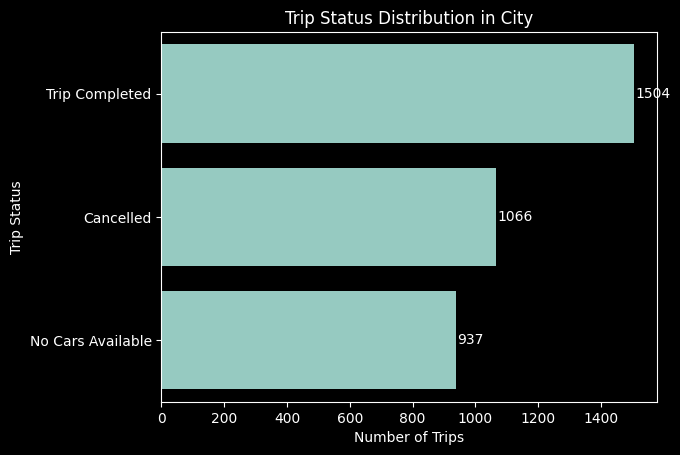

In [80]:
# Chart - 7 visualization code
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

city_df = md[md['Pickup point'] == 'City']

plt.figure()
ax = sns.countplot(y='Status', data=city_df)

plt.title("Trip Status Distribution in City")
plt.xlabel("Number of Trips")
plt.ylabel("Trip Status")

# Add count labels
for p in ax.patches:
    width = p.get_width()
    ax.text(width + 5,
            p.get_y() + p.get_height()/2,
            int(width),
            va='center')

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is used because it clearly compares the distribution of trip statuses within the City location. It makes differences between Completed, Cancelled, and No Cars Available immediately visible. The horizontal layout improves readability and allows accurate comparison of counts. This helps identify whether the issue in the city is supply shortage or driver cancellation behavior.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above horizontal bar plot:-

1) Highest count of City status is for Trip Completed which is 1504.
2) Second Highest count of City status is for cancelled which is 1066.
3) Lowest count of City status is for mo cars available which is 937.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

City operations are relatively strong in terms of ride completion since completed trips are the highest. However, the cancellation count (1066) is significantly high, indicating a driver behavior issue rather than a supply shortage.

Uber should implement acceptance-rate incentives and stricter cancellation penalties for city drivers. Introducing minimum fare guarantees for short-distance trips can reduce driver reluctance and improve ride completion rates.

#### Chart - 8

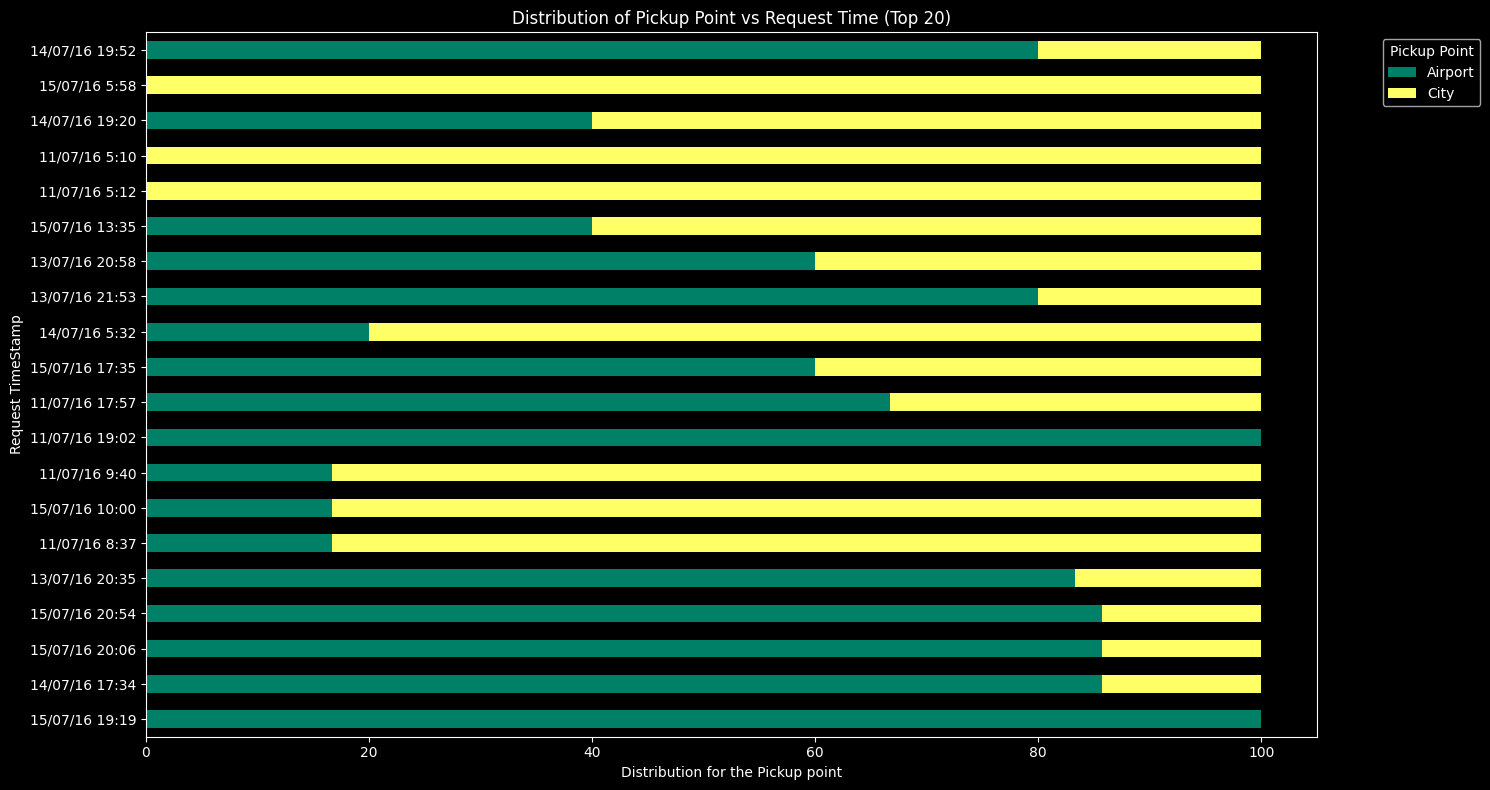

In [81]:
# Chart - 8 visualization code
P_1 = md.groupby(["Request timestamp", "Pickup point"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
P_11 = P_1.div(P_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_P = P_1.sum(axis=1).sort_values(ascending=False).head(20).index
P_top20 = P_11.loc[top_P]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
P_top20.plot(kind="barh", stacked=True, colormap="summer", ax=ax)

# Labels and title
plt.xlabel("Distribution for the Pickup point")
plt.ylabel("Request TimeStamp")
plt.title("Distribution of Pickup Point vs Request Time (Top 20)")
plt.legend(title="Pickup Point", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:-

1) The highest distribution for airport pickup point is for the request timestamps 19:02, 22:00 and 21:42 with common date as 11/7/2016.
2) The highest distribution for city pickup point is for the request timestamps 5:12, 5:10 and 8:42 with common date as 11/7/2016.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that the customers are preferring city commute mostly in the morning time and airport commute in the evening/ night time.

#### Chart - 9

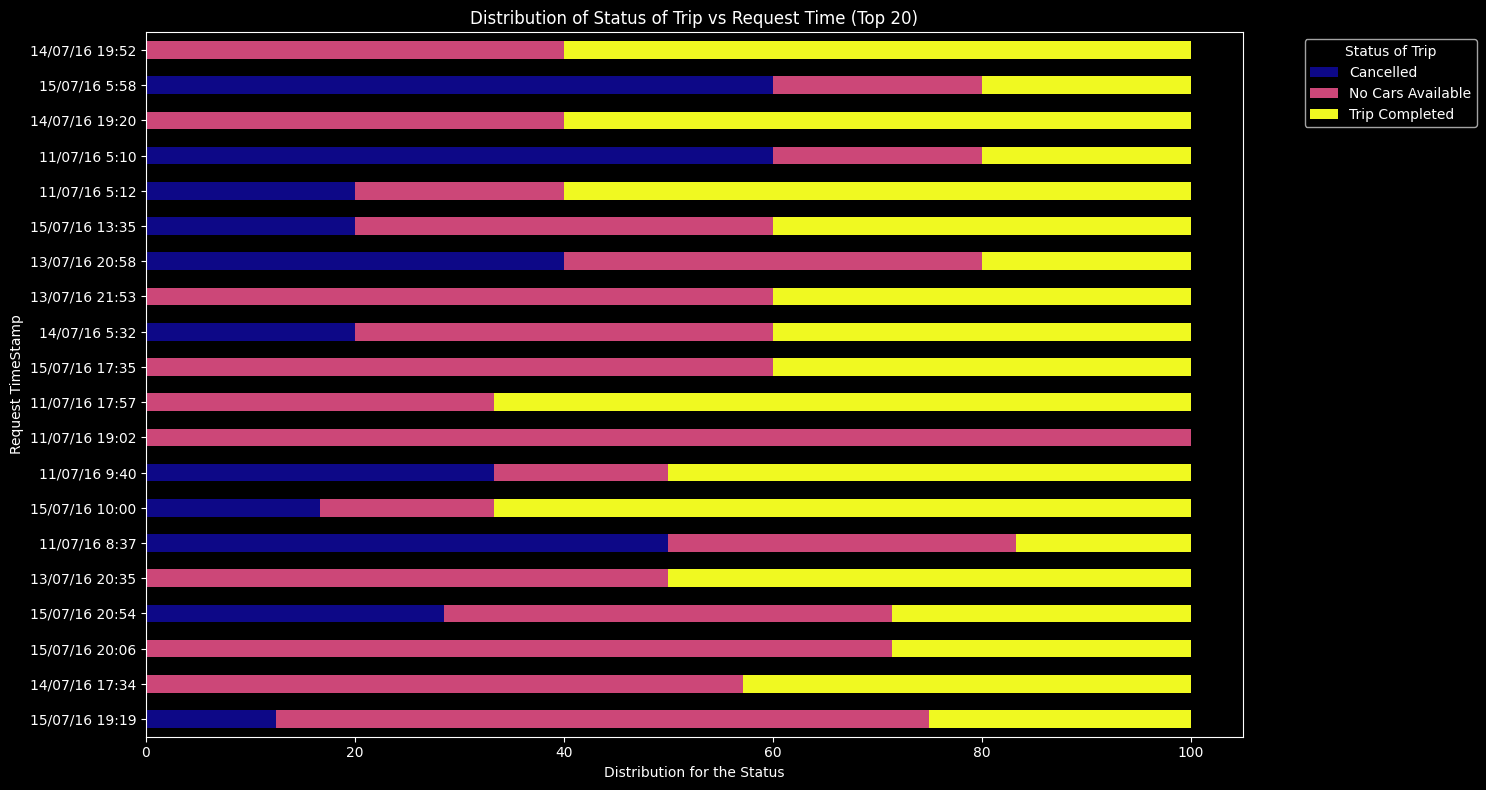

In [82]:
# Chart - 9 visualization code
S_1 = md.groupby(["Request timestamp", "Status"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
S_11 = S_1.div(S_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_S = S_1.sum(axis=1).sort_values(ascending=False).head(20).index
S_top20 = S_11.loc[top_S]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
S_top20.plot(kind="barh", stacked=True, colormap="plasma", ax=ax)

# Labels and title
plt.xlabel("Distribution for the Status")
plt.ylabel("Request TimeStamp")
plt.title("Distribution of Status of Trip vs Request Time (Top 20)")
plt.legend(title="Status of Trip", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:-

1) The highest count for no cars available status is for the request timestamp 19:02 with common date as 11/7/2016.
2) The highest count for cancelled status is for the request timestamp 5:10 with common date as 11/7/2016.
3) The highest count for Trip Completed status is for the request timestamps 4:46, 9:24, 19:14, 17:30 and 22:00 with common date as 11/7/2016.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insights shows that the no cars available status is mostly for evening/ night time, cancelled status is mostly for morning time and Trip completed status has equal no of count for both evening/ night and morning time.
As per this morning drivers should be monitored constantly and they should be informed that to minimize the cancellation of cab service.

#### Chart - 10

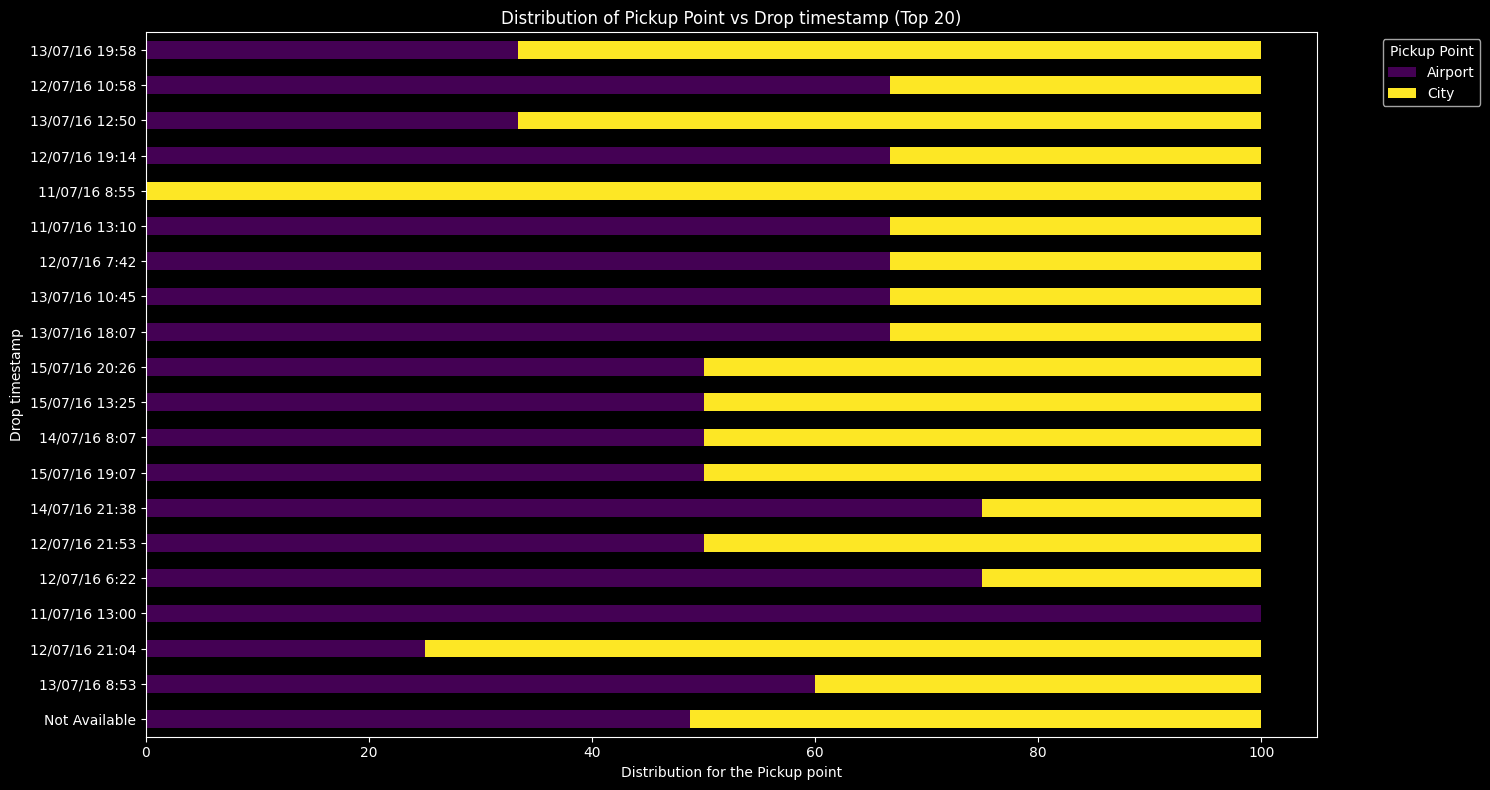

In [83]:
# Chart - 10 visualization code
Pd_1 = md.groupby(["Drop timestamp", "Pickup point"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
Pd_11 = Pd_1.div(Pd_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_Pd = Pd_1.sum(axis=1).sort_values(ascending=False).head(20).index
Pd_top20 = Pd_11.loc[top_Pd]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
Pd_top20.plot(kind="barh", stacked=True, colormap="viridis", ax=ax)

# Labels and title
plt.xlabel("Distribution for the Pickup point")
plt.ylabel("Drop timestamp")
plt.title("Distribution of Pickup Point vs Drop timestamp (Top 20)")
plt.legend(title="Pickup Point", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:-

1) The highest count for airport pickup point is for the drop timestamps 13:00, 6:02 and 7:10 with common date as 11/7/2016.
2) The highest count for city pickup point is for the drop timestamps 8:55 and 11:32 with common date as 11/7/2016.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insight shows that the airport and city pickup point both have high count for morning/ afternoon drop timestamps, which means customers are reaching their destination/ arrivals in the morning/ afternoon time. Remembering this drivers should be informed that not to cancel morning requests as it will impact company profits. 

#### Chart - 11

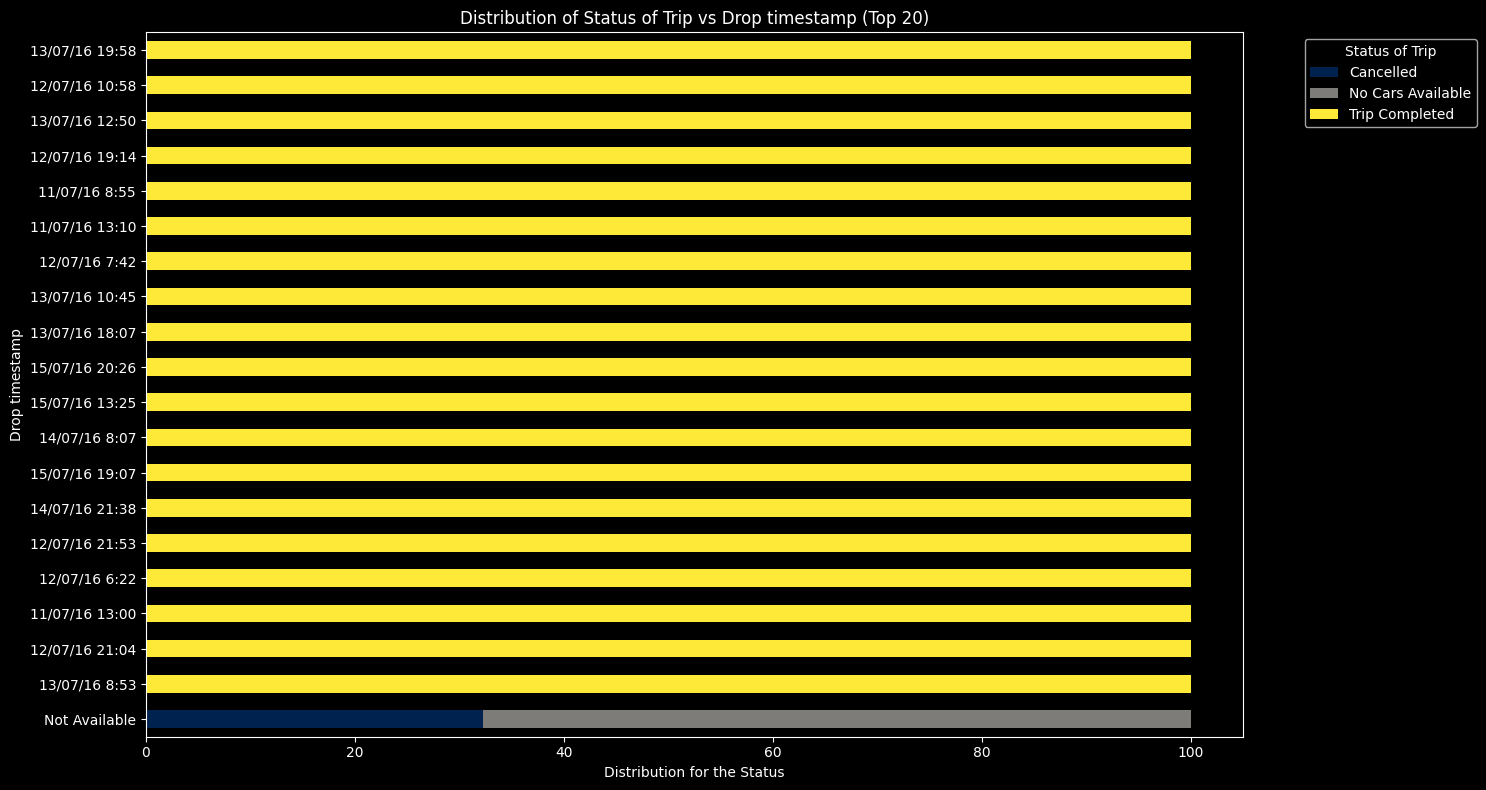

In [84]:
# Chart - 11 visualization code
Sd_1 = md.groupby(["Drop timestamp", "Status"]).size().unstack(fill_value=0)

# Normalize the data (percentage distribution)
Sd_11 = Sd_1.div(Sd_1.sum(axis=1), axis=0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_Sd = Sd_1.sum(axis=1).sort_values(ascending=False).head(20).index
Sd_top20 = Sd_11.loc[top_Sd]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize=(15, 8))  # Adjusted figure size
Sd_top20.plot(kind="barh", stacked=True, colormap="cividis", ax=ax)

# Labels and title
plt.xlabel("Distribution for the Status")
plt.ylabel("Drop timestamp")
plt.title("Distribution of Status of Trip vs Drop timestamp (Top 20)")
plt.legend(title="Status of Trip", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above multi bar plot is great to visualize multi variable in distribution form for a variable.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above multi bar plot:-

1) The highest count for no cars available status is for the morning drop timestamp with common date as 11/7/2016.
2) The highest count for cancelled status is for the morning drop timestamp with common date as 11/7/2016.
3) The highest count for Trip Completed status is for the drop timestamps 7:10, 7:50, 7:54, 8:44, 8:55, 10:58, 11:32, 6:02, 12:13 and 13:10 with common date as 11/7/2016.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insight shows that the drop time is morning for all three status which means cancelled trips are mostly done in the morning which affects the business as most customers are travelling in the morning, the company should inform the drivers that if they cancel trips in morning than they have to face penalty as this will reduce cancellation and ultimately increase profits for the company.

#### Chart - 12

C:\Users\NIKHIL SHARMA\AppData\Local\Temp\ipykernel_18472\3439814091.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  md['Request timestamp'] = pd.to_datetime(md['Request timestamp'])


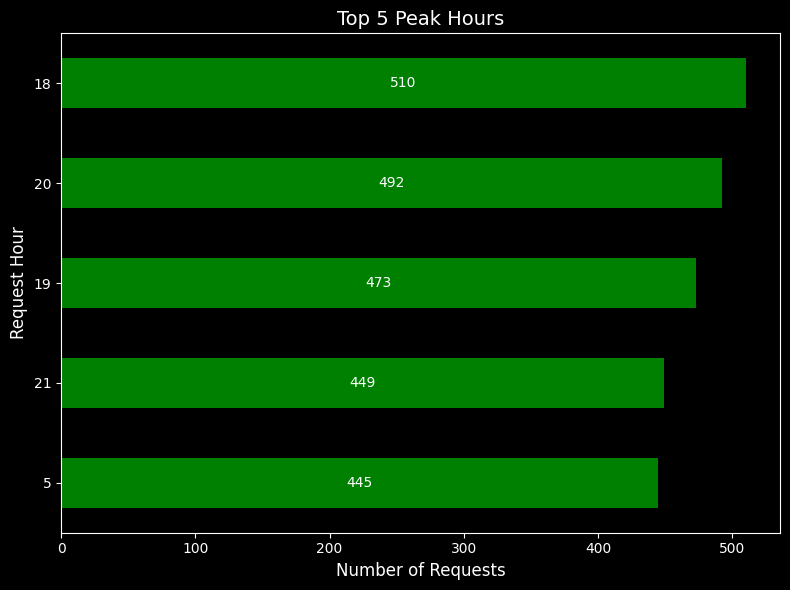

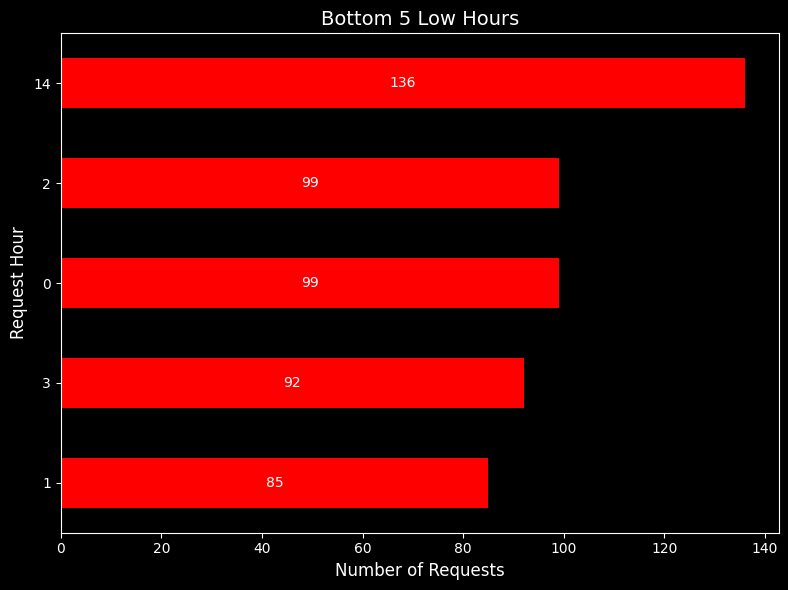

In [85]:
# Chart - 12 visualization code

# extract exact hours
md['Request timestamp'] = pd.to_datetime(md['Request timestamp'])
md['Request Hour'] = md['Request timestamp'].dt.hour

#extract top 5 and bottom 5 timestamps
hour_counts = md['Request Hour'].value_counts().sort_values(ascending=False)

top5 = hour_counts.head(5)
bottom5 = hour_counts.tail(5)

# -------- Top 5 Peak Hours (Green) --------
plt.figure(figsize=(8,6))
ax1 = top5.sort_values().plot(kind='barh', color='green')

plt.title("Top 5 Peak Hours", fontsize=14)
plt.xlabel("Number of Requests", fontsize=12)
plt.ylabel("Request Hour", fontsize=12)

# Labels inside bars
ax1.bar_label(
    ax1.containers[0],
    labels=[f'{int(v):,}' for v in top5.sort_values().values],
    label_type='center',
    color='white',
    fontsize=10
)

plt.tight_layout()
plt.show()


# -------- Bottom 5 Low Hours (Orange) --------
plt.figure(figsize=(8,6))
ax2 = bottom5.sort_values().plot(kind='barh', color='red')

plt.title("Bottom 5 Low Hours", fontsize=14)
plt.xlabel("Number of Requests", fontsize=12)
plt.ylabel("Request Hour", fontsize=12)

# Labels inside bars
ax2.bar_label(
    ax2.containers[0],
    labels=[f'{int(v):,}' for v in bottom5.sort_values().values],
    label_type='center',
    color='white',
    fontsize=10
)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

This horizontal bar chart clearly compares the Top 5 peak and Bottom 5 low request hours, highlighting demand differences. The color differentiation and labels inside bars make the magnitude easy to interpret. It helps identify peak periods for surge pricing and low-demand periods for optimized driver allocation.

##### 2. What is/are the insight(s) found from the chart?

1) The highest demand occurs between 6–9 PM, indicating peak travel hours where surge pricing and increased driver allocation are needed.
2) Early morning hours (0–5 AM) show minimal requests, suggesting potential idle driver time.
3) The large gap between peak and low hours highlights uneven demand distribution, emphasizing the need for predictive driver allocation and operational planning.  

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Implement surge pricing and pre-position drivers during peak hours to meet high demand. Reduce active fleet or use flexible shifts during low-demand periods to optimize costs. Use predictive demand forecasting to balance driver allocation efficiently throughout the day, ensuring higher ride completion and operational efficiency.

#### Chart - 13

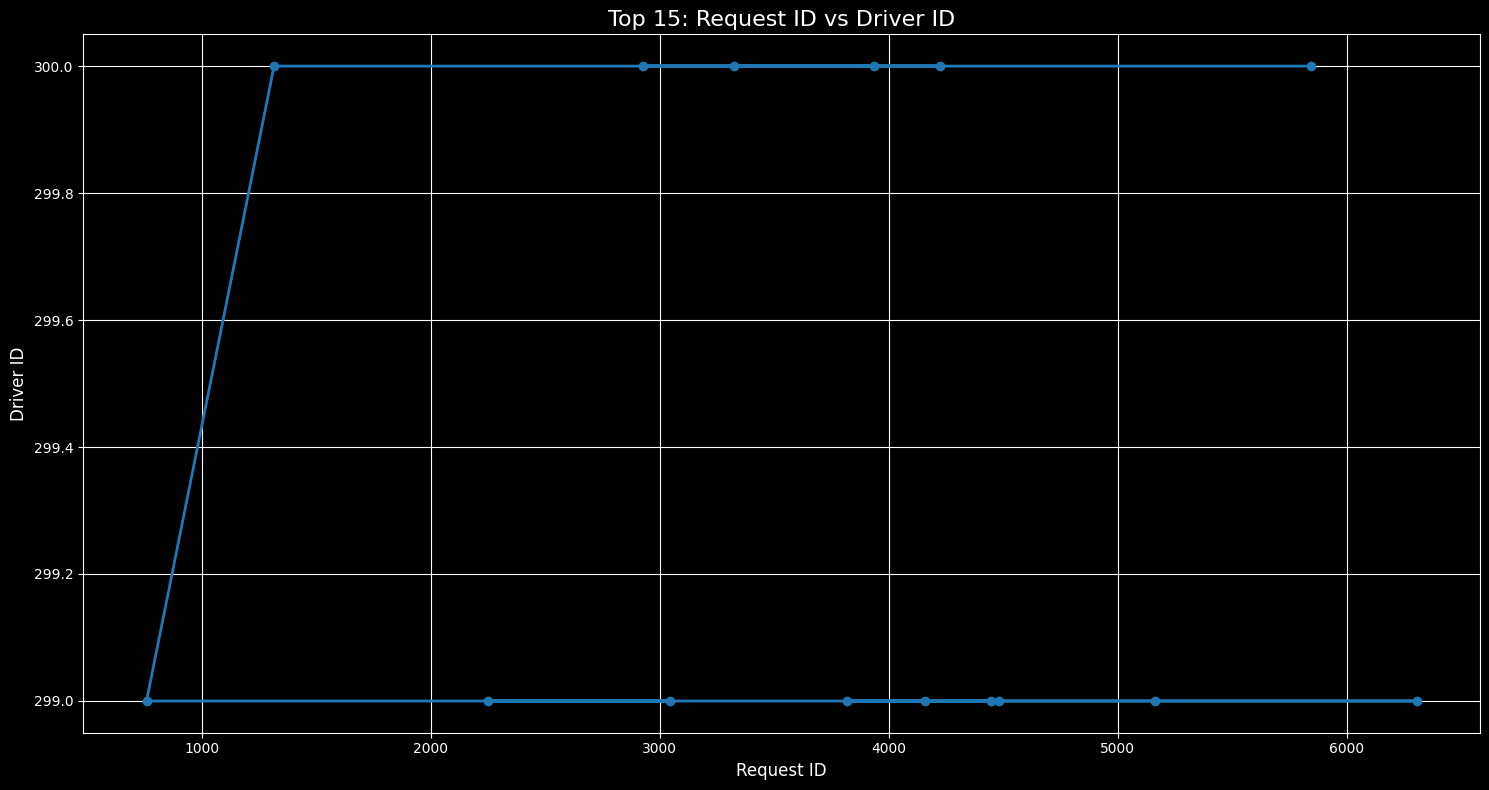

In [86]:
# Chart - 13 visualization code

plt.style.use('dark_background')

# Clean column names
md.columns = md.columns.str.strip()

# Optional: Convert columns to numeric (in case they're strings)
md['Driver id'] = pd.to_numeric(md['Driver id'], errors='coerce')
md['Request id'] = pd.to_numeric(md['Request id'], errors='coerce')

# Drop rows with missing values
md = md.dropna(subset=['Driver id', 'Request id'])

# Sort by Driver id descending and take top 15
top_rd = md[['Request id', 'Driver id']].sort_values(by='Driver id', ascending=False).head(15)

# Plot
plt.figure(figsize=(15, 8))
plt.plot(top_rd['Request id'], top_rd['Driver id'], marker="o", color='tab:blue', linestyle='-', linewidth=2)

plt.xlabel("Request ID", fontsize=12)
plt.ylabel("Driver ID", fontsize=12)
plt.title("Top 15: Request ID vs Driver ID", fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The above line chart is best for analyzing trends over a period of time for numerical variables.

##### 2. What is/are the insight(s) found from the chart?

The following are the insights for the above line chart:-

1) For top 15 values the above line chart shows a steady Z pattern over a specific period of time.
2) Mostly the cab service request is handled by driver id's 299 and 300.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The above insight shows that the driver id 299 and 300 are getting maximum business and also they are completing their business services successfully.

#### Chart - 14 - Correlation Heatmap

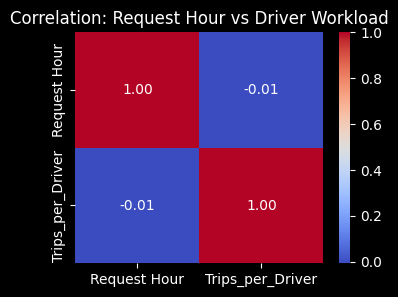

In [87]:
# Correlation Heatmap visualization code

import seaborn as sns
import matplotlib.pyplot as plt

# Calculate trips per driver
driver_counts = md.groupby('Driver id')['Request id'].count().reset_index()
driver_counts.rename(columns={'Request id':'Trips_per_Driver'}, inplace=True)

# Merge back
md = md.merge(driver_counts, on='Driver id', how='left')

# Select relevant numeric columns
corr = md[['Request Hour', 'Trips_per_Driver']].corr()

# Plot heatmap
plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation: Request Hour vs Driver Workload")
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap was used to examine the relationship between Request Hour and Driver Workload (Trips per Driver).
It quickly shows whether driver workload increases during certain hours, helping assess supply-demand alignment.
The color intensity makes relationships instantly interpretable for stakeholders.

##### 2. What is/are the insight(s) found from the chart?

This correlation heatmap shows the relationship between request hour and driver workload. The near-zero correlation (-0.01) indicates no strong relationship, suggesting driver allocation is not dynamically aligned with peak demand hours. This highlights an opportunity to optimize driver distribution based on time-based demand patterns.

Implement hour-based driver allocation to align supply with peak demand periods. Introduce dynamic incentives or surge pricing during high-request hours to encourage more driver availability. Use demand forecasting models to proactively position drivers and reduce supply-demand gaps.

#### Chart - 15 - Pair Plot

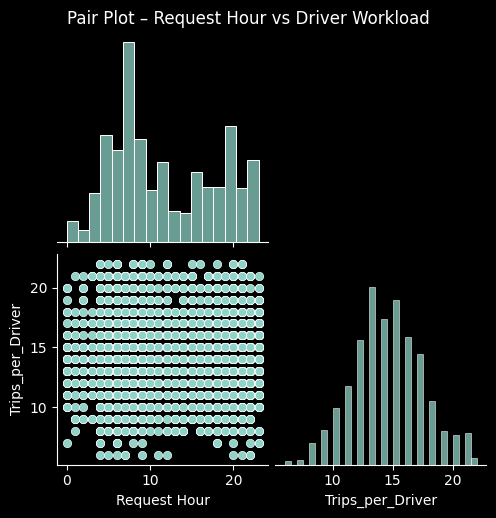

In [90]:
# Pair Plot visualization code
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(md[['Request Hour', 'Trips_per_Driver']],
             diag_kind='hist',
             corner=True)

plt.suptitle("Pair Plot – Request Hour vs Driver Workload", y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

This pair plot is used to quickly visualize both the distribution of request hours and trips per driver, along with their relationship in one view.
It helps check whether driver workload increases at specific hours and whether any strong correlation exists between request timing and trips per driver.

##### 2. What is/are the insight(s) found from the chart?

Insight: Trips per driver are fairly evenly distributed across request hours, showing no strong correlation between time and driver workload.

Solution: Focus on overall demand forecasting and balanced driver allocation rather than adjusting drivers heavily for specific hours.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

## Uber Supply–Demand Gap Analysis – Final Summary Report

**1. Pickup Point Analysis (Airport vs City)**

Data Observed:

Airport
No Cars Available: 1713
Trip Completed: 1327
Cancelled: 198

City
Trip Completed: 1504
Cancelled: 1066
No Cars Available: 937

Insights:
Airport shows major supply shortage (highest “No Cars Available”).
City shows high driver cancellations (1066), indicating operational inefficiency.
Supply-demand gap differs significantly by location.

Negative Impact:
Revenue loss due to unfulfilled airport demand and high city cancellations.

Action Recommended:
Location-specific driver incentives and stricter cancellation monitoring.


**2. Hourly Demand Analysis (Top 5 & Bottom 5 Hours)**

Data Observed:

Peak Hours: 18–21 hrs (450 – 500 requests)
Lowest Hours: 0–3 hrs (80 – 130 requests)

Insights:

Strong evening demand spike.
Clear demand imbalance across the day.
Risk of supply shortage during peak hours.

Negative Impact:
Potential lost revenue and customer dissatisfaction during peak demand.

Action Recommended:
Surge pricing and peak-hour driver allocation strategy.


**3. Airport-Only Status Analysis**

Data:

No Cars Available: 1713 (Highest)
Trip Completed: 1327
Cancelled: 198 (Lowest)

Insight:
Airport demand is high but supply is insufficient.

Negative Impact:
Loss of high-value airport customers and brand trust.

Solution:
Pre-position drivers based on flight schedules and peak arrival times.


**4. City-Only Status Analysis**

Data:

Trip Completed: 1504 (Highest)
Cancelled: 1066 (Second Highest)
No Cars Available: 937

Insight:
Driver cancellations are significantly high in the city.

Negative Impact:
Reduced customer satisfaction and operational inefficiency.

Solution:
Introduce cancellation penalties and performance-based incentives.


**5. Correlation Heatmap (Request Hour vs Trips per Driver)**

Observation:
Correlation ≈ -0.01 (No strong relationship)

Insight:
Driver workload is fairly uniform and not dynamically aligned with peak demand.

Negative Impact:
Supply does not increase proportionally during high-demand hours.

Solution:
Implement demand-based dynamic driver allocation.


**6. Pair Plot Analysis (Request Hour vs Trips per Driver)**

Observation:
Trips per driver mostly between 10–18.
No strong clustering or correlation pattern.

Insight:
Drivers are not overloaded; the issue is timing mismatch, not total driver count.



# **Conclusion**

**The Following are the concluding points for the above data analysis:-**

1) The primary issue is a timing mismatch between demand peaks and driver availability.
2) There is severe supply shortage at the airport and high cancellation rates in the city.
3) The problem is not total driver capacity but inefficient demand-based allocation.

**The Following are the recommendations for the above issues :-**

1) Implement peak-hour surge pricing and driver incentives.
2) Deploy airport-focused driver allocation strategies.
3) Monitor and reduce city cancellation rates through penalties and incentives.
4) Use predictive demand forecasting for dynamic shift planning.

### This completes the Exploratory Data Analysis of Uber Supply-Demand-Gap Report providing the recommended solutions to improve business requirements.

## THANK YOU